In [ ]:
import json
import numpy as np
import os
from scipy.stats import iqr, zscore

# Load all json files from results folder
results_dir = "results_07-31-2025_gds"
info_dir = "07-31-2025_gds"
json_files = sorted([f for f in os.listdir(results_dir) if f.endswith('.gds.json')])

# Parameters to extract distortion factors for (in order)
param_names = ["W1", "W2", "W3", "W4", "L1", "L2"]

# Build X (positions) and Y (distortion_factors)
X = []
Y = []
Y_log = [] # Add array for log distortion factors
for json_file in json_files:
    # Load results json file
    with open(os.path.join(results_dir, json_file), 'r') as f:
        data = json.load(f)

    # Load corresponding info json file
    info_num = json_file.replace('outline', '').replace('.gds.json', '')
    info_file = f"info{info_num}.json"
    with open(os.path.join(info_dir, info_file), 'r') as f:
        info_data = json.load(f)
    print(info_data)
    # Get x,y position from info file
    X.append([info_data['x']/3000, info_data['y']/3000])

    # Get distortion factors for each parameter
    y_row = []
    y_log_row = [] # Add row for log values
    for param in param_names:
        df = data["distortion_factors"][param]["distortion_factor"]
        if df is None:
            df = 1.0
        y_row.append(1.0/df)
        y_log_row.append(np.log(1.0/df)) # Take log of distortion factor
    Y.append(y_row)
    Y_log.append(y_log_row)

X = np.array(X)  # shape (n_files, 2)
Y = np.array(Y)  # shape (n_files, 6)
Y_log = np.array(Y_log) # Convert log values to array

# --- Normalizations for Y ---
# Interquartile range normalization (subtract median, divide by IQR)
y_norm_iqr = np.zeros_like(Y)
iqr_medians = []
iqr_values = []
for i in range(Y.shape[1]):
    med = np.median(Y[:, i])
    iqr_val = iqr(Y[:, i])
    iqr_medians.append(med)
    iqr_values.append(iqr_val)
    if iqr_val == 0:
        y_norm_iqr[:, i] = Y[:, i] - med  # avoid division by zero
    else:
        y_norm_iqr[:, i] = (Y[:, i] - med) / iqr_val

def invert_iqr_normalization(y_norm, medians=iqr_medians, iqrs=iqr_values):
    """
    Convert IQR-normalized outputs back to original scale.
    y_norm: array-like, shape (..., n_outputs)
    medians: list of medians used for normalization
    iqrs: list of IQRs used for normalization
    Returns: array-like, same shape as y_norm
    """
    y_norm = np.asarray(y_norm)
    y_orig = np.zeros_like(y_norm)
    for i in range(y_norm.shape[-1]):
        if iqrs[i] == 0:
            y_orig[..., i] = y_norm[..., i] + medians[i]
        else:
            y_orig[..., i] = y_norm[..., i] * iqrs[i] + medians[i]
    return y_orig

# Z-score normalization (subtract mean, divide by std)
y_norm_zscore = zscore(Y, axis=0)

print(Y)
print(X)
print(Y_log) # Print the log values


{'original_file': 'Design 1 zoom.jpg', 'x': -1725.3, 'y': 1559.5, 'L1': 2000.0, 'L2': 800.0, 'W1': 300.0, 'W2': 700.0, 'W3': 1000.0, 'W4': 300.0}
{'original_file': 'Design 10 zoom.jpg', 'x': 1274.7, 'y': 759.5, 'L1': 1000.0, 'L2': 2000.0, 'W1': 300.0, 'W2': 900.0, 'W3': 1200.0, 'W4': 300.0}
{'original_file': 'Design 19 zoom.jpg', 'x': -225.3, 'y': -840.5, 'L1': 2000.0, 'L2': 800.0, 'W1': 300.0, 'W2': 500.0, 'W3': 1000.0, 'W4': 300.0}
{'original_file': 'Design 2 zoom.jpg', 'x': -975.3, 'y': 1559.5, 'L1': 2500.0, 'L2': 1200.0, 'W1': 300.0, 'W2': 700.0, 'W3': 1400.0, 'W4': 200.0}
{'original_file': 'Design 20 zoom.jpg', 'x': 524.7, 'y': -840.5, 'L1': 2000.0, 'L2': 1200.0, 'W1': 500.0, 'W2': 700.0, 'W3': 1200.0, 'W4': 100.0}
{'original_file': 'Design 21 zoom.jpg', 'x': 1274.7, 'y': -840.5, 'L1': 2500.0, 'L2': 1200.0, 'W1': 300.0, 'W2': 500.0, 'W3': 1200.0, 'W4': 300.0}
{'original_file': 'Design 22 zoom.jpg', 'x': 2024.7, 'y': -840.5, 'L1': 2000.0, 'L2': 1200.0, 'W1': 500.0, 'W2': 700.0, 'W3

## Gaussian Process Regression (GPR) for 2D Warping

### 1. Intuition & Kernel

A Gaussian Process (GP) defines a distribution over functions \(f:\mathbb{R}^2\to\mathbb{R}\) such that any finite collection of outputs is jointly Gaussian.  You specify

- a **mean function** $m(\mathbf x)$ (often set to zero),  
- a **covariance kernel** $k(\mathbf x,\mathbf x')$,  

so that
$$
f(\mathbf x)\,\sim\,\mathcal{GP}\bigl(m(\mathbf x),\,k(\mathbf x,\mathbf x')\bigr).
$$

A popular choice is the **squared‑exponential (RBF) kernel**:

$$
k(\mathbf x,\mathbf x')
= \sigma_f^2
\exp\!\Bigl(-\tfrac{1}{2\ell^2}\|\mathbf x-\mathbf x'\|^2\Bigr),
$$
where  
- $\ell$ controls the “length‑scale” (how quickly warps vary in space),  
- $\sigma_f^2$ is the signal variance (overall warp magnitude).

---

### 2. Mathematical Formulation

Given training inputs $\{\mathbf x_i\}_{i=1}^n\subset\mathbb R^2$ and observed distortions $y_i = f(\mathbf x_i) + \varepsilon_i$ (with noise $\varepsilon_i\sim\mathcal N(0,\sigma_n^2)$), stack

$$
\mathbf K = \bigl[k(\mathbf x_i,\mathbf x_j)\bigr]_{i,j=1}^n,\quad
\mathbf y = (y_1,\dots,y_n)^\top.
$$

For a new query $\mathbf x_*$, the **posterior predictive** is
$$
\begin{aligned}
\hat f(\mathbf x_*)
&= \mathbf k_*^\top \bigl(\mathbf K + \sigma_n^2 \mathbf I\bigr)^{-1}\mathbf y,\\[6pt]
\mathrm{Var}\bigl[f(\mathbf x_*)\bigr]
&= k(\mathbf x_*,\mathbf x_*)
- \mathbf k_*^\top \bigl(\mathbf K + \sigma_n^2 \mathbf I\bigr)^{-1} \mathbf k_*,
\end{aligned}
$$
where $\mathbf k_* = [\,k(\mathbf x_i,\mathbf x_*)\,]_{i=1}^n$.

To handle **5 outputs**, you can either  
- train 5 independent GPs (one per distortion channel), or  
- use a **multi‑output GP** (e.g. with an intrinsic coregionalization model) that captures correlations among channels.

---

### 3. Motivation for Positional Warping

1. **Controlled Smoothness**  
   The kernel length‑scale $\ell$ directly governs how local or global your warp is—small $\ell$ lets you capture sharp local bends; large $\ell$ enforces broad, gentle deformations.

2. **Uncertainty Quantification**  
   GPR gives you a predictive variance at each $(x,y)$, flagging regions where you lack samples—so you know where to add more control points.

3. **Non‑Parametric Flexibility**  
   Without prescribing a fixed polynomial or basis, GPR adapts complexity to the data, automatically smoothing noisy measurements while still fitting true warp patterns.

4. **Bayesian Model Selection**  
   You can optimize kernel hyperparameters $(\ell,\sigma_f,\sigma_n)$ by maximizing the marginal likelihood, balancing data fit vs. warp complexity.

---

### 4. Practical Advantages

| Feature                     | GPR                                          | TPS                                         |
|-----------------------------|----------------------------------------------|---------------------------------------------|
| Smoothness control         | Kernel‑driven length‑scale \(\ell\)          | Implicit via bending‑energy minimization    |
| Uncertainty estimates      | Yes (posterior variance)                     | No                                          |
| Global vs. local behavior  | Tunable via kernel (stationary vs. non‑stat.)| Globally smooth but no length‑scale tuning  |
| Noise handling             | Explicit noise term $\sigma_n^2$           | Requires smoothing parameter $s$          |
| Computational cost         | $\mathcal O(n^3)$ for training, $\mathcal O(n^2)$ per query | $\mathcal O(n^3)$ solve, $\mathcal O(n)$ per query |
| Multi‑output correlations  | Via coregionalization kernels                | Fit each channel independently              |

---

> **Bottom Line**:  
> - Use **GPR** when you want principled smoothness control, uncertainty quantification, and Bayesian hyperparameter tuning.  
> - It’s especially powerful in 2D warping when sample density varies—GPR tells you where its predictions are less certain, guiding further data collection.  


In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

# --- 1) Generate or load your data ---
X = X      # 2D inputs
Y = Y     # 5 distortion outputs

# --- 2) Build a kernel and wrap GPR for multi-output ---
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 2.0))
base_gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,            # noise level
    normalize_y=True,
    n_restarts_optimizer=5
)
gpr = MultiOutputRegressor(base_gp)

# --- 3) Fit the model ---
gpr.fit(X, Y)

# --- 4) Query new locations ---
X_query = np.array([[1000, 0],
                    [-400, 0],
                    [200, 0]])/2000  # e.g. 3 query points
# MultiOutputRegressor does not support return_std directly.
# To get mean and std for each output, loop over the underlying estimators:
Y_pred = []
Y_std = []
for i, est in enumerate(gpr.estimators_):
    mean, std = est.predict(X_query, return_std=True)
    Y_pred.append(mean)
    Y_std.append(std)
Y_pred = np.vstack(Y_pred).T   # shape (n_query, n_outputs)
Y_std = np.vstack(Y_std).T     # shape (n_query, n_outputs)

print("Predicted distortions:\n", Y_pred)
print("Uncertainties:\n", Y_std)


Predicted distortions:
 [[0.86479641 0.97491112 0.95162884 0.99927924 0.98295211 0.95073475]
 [0.86479641 1.00649499 0.94979191 0.92973394 0.98295211 0.95073474]
 [0.86479641 1.01565719 0.94829073 0.94018246 0.98295211 0.95073471]]
Uncertainties:
 [[0.03069117 0.02695282 0.02016071 0.04357249 0.02963217 0.03376791]
 [0.03069117 0.03296807 0.02186227 0.05327145 0.02963217 0.03376791]
 [0.03069117 0.02687748 0.02014238 0.04347934 0.02963217 0.03376791]]


/Users/jacksonkay/Desktop/Active/ai-fab/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jacksonkay/Desktop/Active/ai-fab/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


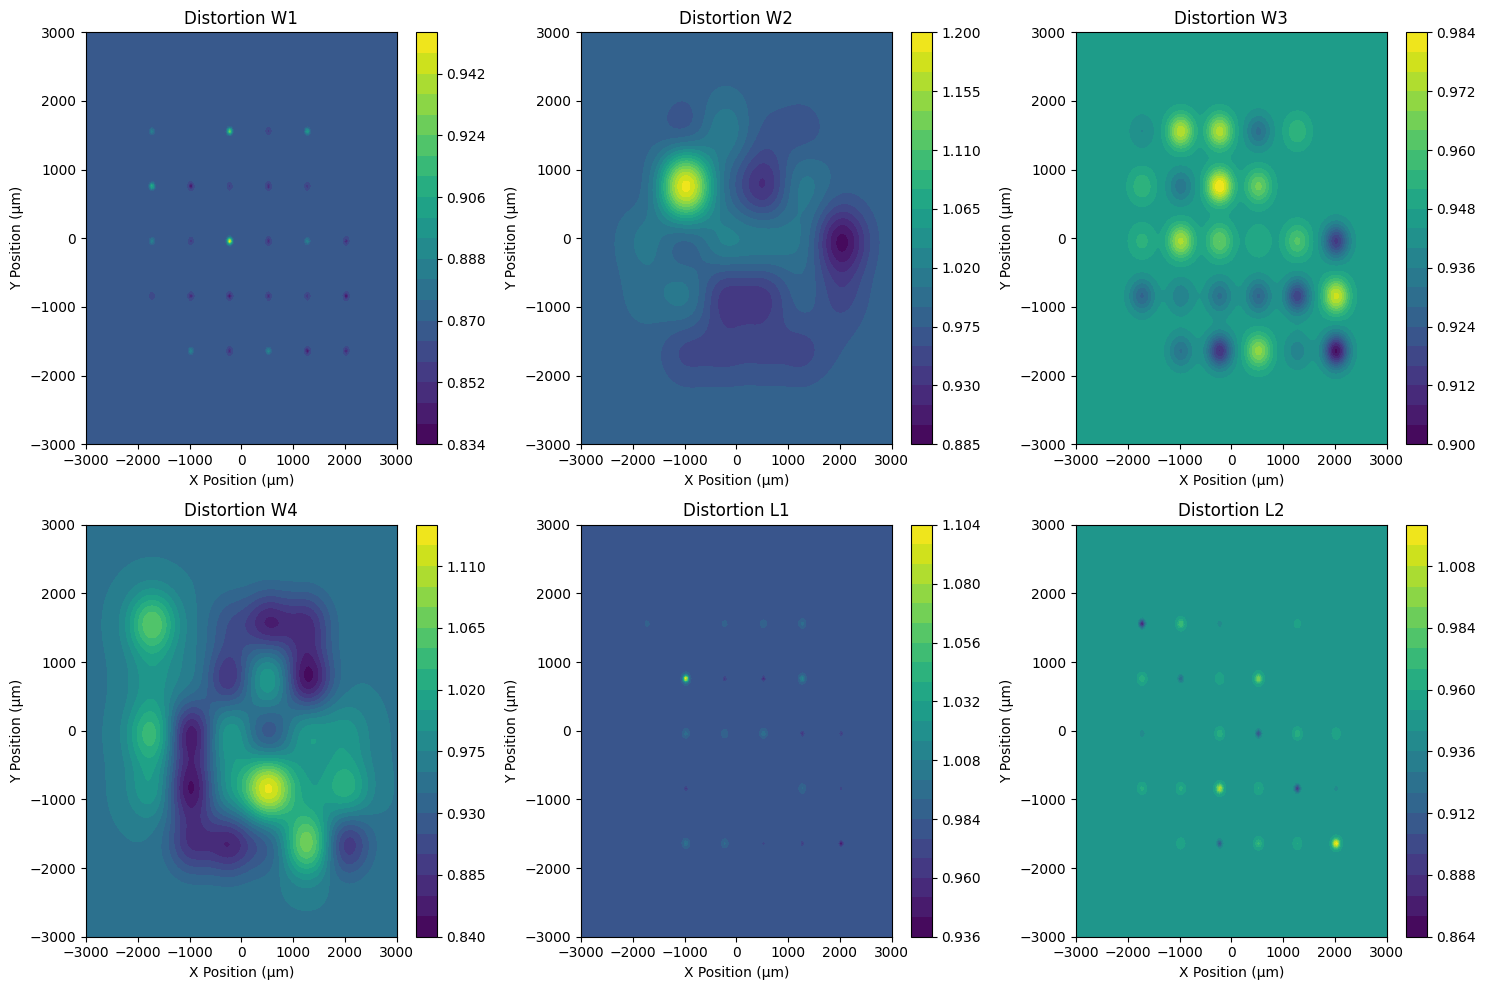

In [15]:
# Generate a 2D grid of input points
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)

# Flatten the grid points
xq = X.flatten()
yq = Y.flatten()

# Get predictions for each point
Y_pred = []
for est in gpr.estimators_:
    pred = est.predict(np.column_stack((xq, yq)))
    Y_pred.append(pred)
Y_pred = np.array(Y_pred).T

# Reshape predictions back to 2D grid
Y_pred = Y_pred.reshape(200, 200, len(param_names))

# Scale x,y coordinates for display
X_display = X * 3000
Y_display = Y * 3000

# Create subplots for each parameter
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

for i, name in enumerate(param_names):
    im = axs[i].contourf(X_display, Y_display, Y_pred[:,:,i], levels=20)
    axs[i].set_title(f'Distortion {name}')
    axs[i].set_xlabel('X Position (μm)')
    axs[i].set_ylabel('Y Position (μm)')
    plt.colorbar(im, ax=axs[i])

plt.tight_layout()
plt.show()

## 3. Thin‑Plate Spline (TPS) / Biharmonic Spline

### 3.1 Intuition & Kernel

A thin‑plate spline finds the smoothest possible surface that passes through your data points by minimizing the bending (second‐derivative) energy of a “thin metal plate.”  In 2D the radial basis function (RBF) kernel is

$$
\phi(r) = r^2 \ln(r),
\qquad
r = \sqrt{(x - x_i)^2 + (y - y_i)^2}.
$$

Because $\phi(r)$ grows like $r^2\ln r$, it enforces a globally smooth surface with continuous second derivatives.

---

### 3.2 Mathematical Formulation

Given $n$ samples $\{(x_i,y_i,f_i)\}_{i=1}^n$, we solve for weights $\mathbf w=(w_1,\dots,w_n)^T$ and affine coeffs $\mathbf a=(a_0,a_1,a_2)^T$ by enforcing interpolation and minimal bending‐energy.  Define

$$
K_{ij} = \phi\bigl(\|(x_i,y_i)-(x_j,y_j)\|\bigr),
\quad
P = 
\begin{pmatrix}
1 & x_1 & y_1 \\
1 & x_2 & y_2 \\
\vdots & \vdots & \vdots \\
1 & x_n & y_n
\end{pmatrix},
\quad
\mathbf f = 
\begin{pmatrix}
f_1\\
f_2\\
\vdots\\
f_n
\end{pmatrix}.
$$

We solve the linear system

$$
\begin{pmatrix}
K & P \\
P^\top & 0
\end{pmatrix}
\begin{pmatrix}
\mathbf w \\[6pt] \mathbf a
\end{pmatrix}
=
\begin{pmatrix}
\mathbf f \\[3pt] \mathbf 0
\end{pmatrix}.
$$

The TPS interpolant at a new point $(x,y)$ is

$$
\hat f(x,y)
= \sum_{i=1}^n w_i\,\phi\bigl(\|(x,y)-(x_i,y_i)\|\bigr)
\;+\;
a_0 \;+\; a_1\,x \;+\; a_2\,y.
$$


## Why Thin‑Plate Splines Excel for 2D Warping

Thin‑plate splines (TPS) are a go‑to choice for 2D image and coordinate warping because they combine global smoothness with exact control‑point fitting. Here’s why they work so well:

---

### 1. **Minimal Bending Energy**  
- **Global Smoothness**  
  TPS minimizes the integrated square of all second derivatives (the “bending energy”), so the deformed surface has as little unwanted curvature as possible.  
- **Natural Interpolation**  
  By solving a single linear system for all control points, TPS guarantees that every point in the domain “feels” the influence of every control point, producing a globally coherent warp.

---

### 2. **Exact Control‑Point Matching**  
- **Interpolation Constraint**  
  TPS enforces $s(x_i,y_i) = d_i$ exactly (when smoothing parameter $s=0$), ensuring that the prescribed displacements at your sample locations are met without compromise.  
- **Affine + Non‑Affine Components**  
  The built‑in affine term handles large‑scale translations, rotations, and scaling, while the RBF term captures local, non‑linear deformations.

---

### 3. **Analytic Invertibility**  
- **Invertible Mapping**  
  Under mild conditions (no degenerate triangulation), the TPS warp is invertible and smooth in both directions. This is crucial for tasks like image morphing, where you often need both forward and backward warps.  
- **Closed‑Form Expression**  
  You get explicit functions for both warp and inverse (by swapping source/destination control points), without resorting to iterative search.

---

### 4. **Flexibility & Control**  
- **Adjustable Smoothness**  
  By introducing a smoothing parameter $s>0$, you can trade exact fitting for noise robustness, which is helpful if your control points are noisy or imprecise.  
- **Dense or Sparse Control**  
  TPS scales to both sparse landmark‑based warping (e.g.\ facial keypoints) and dense grid warps (e.g.\ full‑frame image registration).

---

### 5. **Wide Adoption & Tool Support**  
- **Image Registration**  
  TPS is a standard in medical imaging (MRI/CT alignment) and remote sensing.  
- **Facial Animation & Morphing**  
  Used in graphics pipelines to smoothly blend between expressions or faces.  
- **Computer Vision Libraries**  
  Supported out of the box in SciPy (`SmoothBivariateSpline`) and specialized toolkits.

---

### 6. **Comparisons to Alternatives**  
| Property                | TPS (Biharmonic)        | Piecewise Affine          | Polynomial Warps       |
|-------------------------|-------------------------|---------------------------|------------------------|
| Smoothness              | \(C^2\) global          | \(C^0\) (linear in pieces)| Varies by degree       |
| Exact Control‑Point Fit | Yes (when \(s=0\))      | Yes                       | Depends on fit         |
| Ease of Inversion       | Closed‑form             | Approximate (triangle lookup)| Often iterative    |
| Computational Cost      | \(O(n^3)\) solve        | \(O(n)\) mesh build       | \(O(n)\) basis solve   |
| Noise Robustness        | Tunable via \(s\)       | No smoothing parameter    | Possible via regression|

---

> **Bottom Line**: TPS gives you  
> 1. a **single**, globally‑smooth solution  
> 2. **exact** matching of landmarks  
> 3. a **closed‑form**, invertible warp  
> making it ideal for precise 2D warping tasks such as image registration, morphing, and spatial correction.  


In [13]:
import numpy as np
from scipy.interpolate import Rbf

# --- 1) Generate or load your data ---

print(len(X))
print(len(Y))
X = X
Y = y_norm_iqr

# Split X into x and y coords
x = X[:, 0]
y = X[:, 1]

# --- 2) Build one TPS interpolator per output dimension ---
rbf_list = []
for i in range(6):  # Changed to 6 dimensions
    di = Y[:, i]
    # function='thin_plate' yields a biharmonic (TPS) kernel
    rbf = Rbf(x, y, di,
              function='thin_plate',
              smooth=0)   # increase smooth>0 to regularize/noise-smooth
    rbf_list.append(rbf)

# --- 3) Define a predictor function ---
def tps_predict(xq: np.ndarray, yq: np.ndarray) -> np.ndarray:
    """
    xq, yq: arrays of the same shape, e.g. (m,)
    returns: array of shape (m, 6)  # Updated docstring
    """
    # stack each rbf's output
    out = [rbf(xq, yq) for rbf in rbf_list]
    return np.vstack(out).T

# --- 4) Example query ---
xq = np.array([1000, -400, 200])/3000
yq = np.array([0, 0, 0])/3000
Y_tps = tps_predict(xq, yq)   # shape (3, 6)  # Updated comment
print("TPS predictions:\n", invert_iqr_normalization(Y_tps, iqr_medians, iqr_values))


27
27
TPS predictions:
 [[0.86610837 1.01207847 0.95903363 0.96697349 0.97124192 0.94205978]
 [0.93479283 1.02263964 0.96773092 0.96566592 0.99308228 0.96706584]
 [0.88779149 1.00932804 0.95780177 0.96710103 0.99189756 0.92981197]]


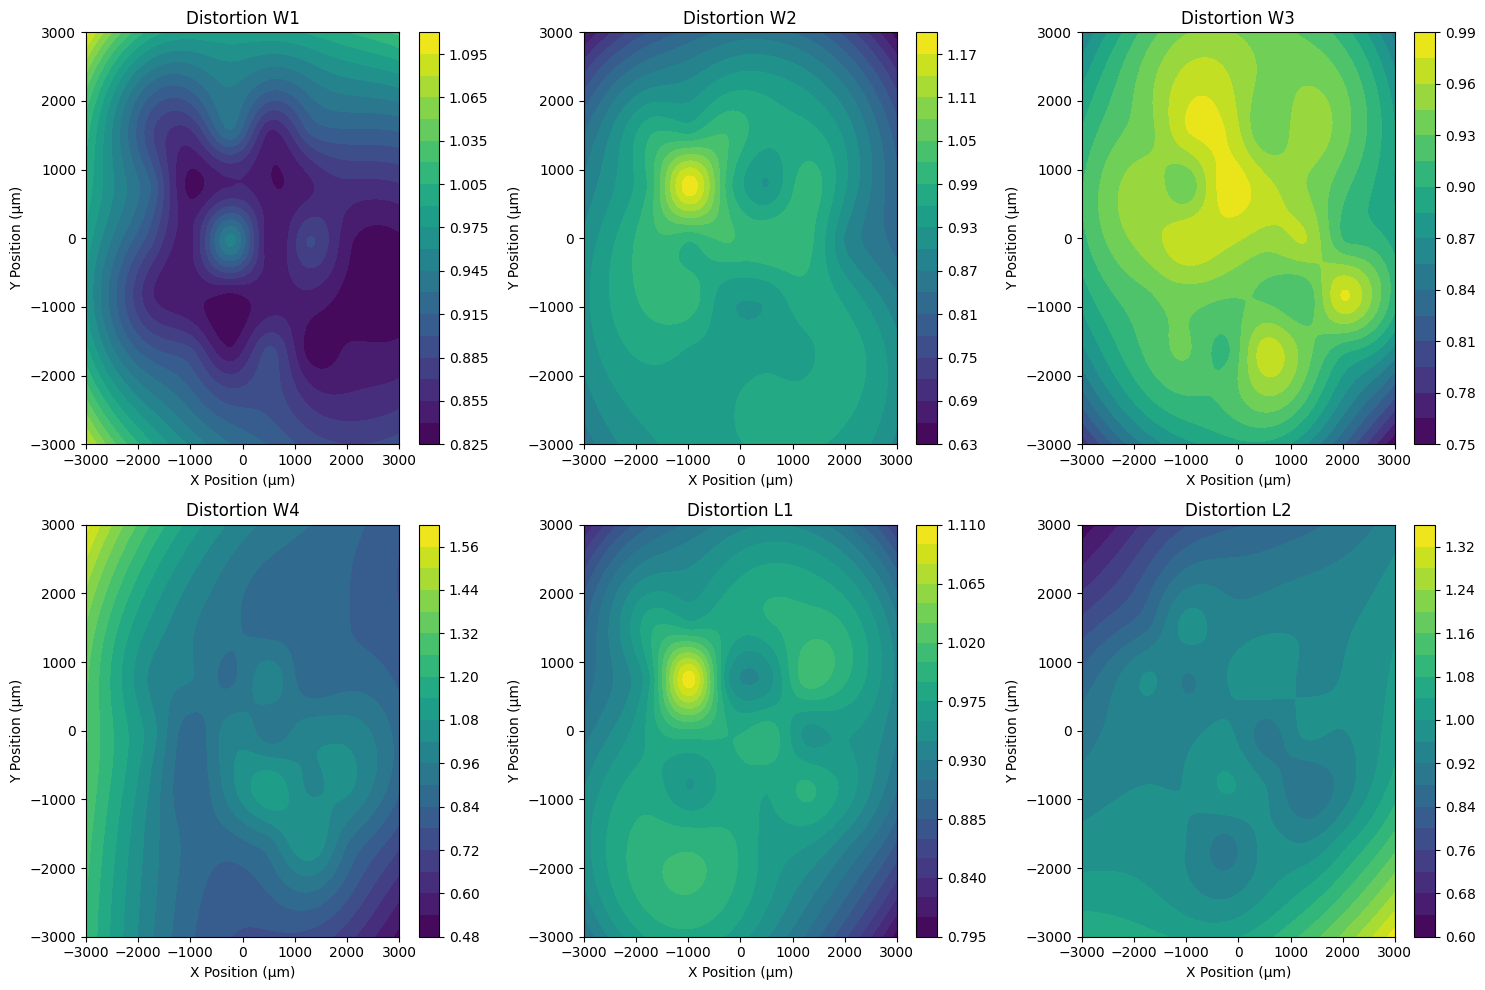

In [ ]:
# Generate a 2D grid of input points
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)

# Flatten the grid points
xq = X.flatten()
yq = Y.flatten()

# Get raw TPS predictions and invert the IQR normalization
Y_tps_raw = tps_predict(xq, yq)  # shape (40000, 6)
Y_tps = invert_iqr_normalization(Y_tps_raw, iqr_medians, iqr_values)

# Reshape predictions back to 2D grid
Y_tps = Y_tps.reshape(200, 200, 6)

# Scale x,y coordinates for display
X_display = X * 3000
Y_display = Y * 3000

# Create subplots for each parameter
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

for i, name in enumerate(param_names):
    im = axs[i].contourf(X_display, Y_display, Y_tps[:,:,i], levels=20)
    axs[i].set_title(f'Distortion {name}')
    axs[i].set_xlabel('X Position (μm)')
    axs[i].set_ylabel('Y Position (μm)')
    plt.colorbar(im, ax=axs[i])

plt.tight_layout()
plt.show()